In [2]:
!pip install catboost lightgbm xgboost optuna shap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 38.1 MB/s eta 0:00:00


In [15]:
from google.colab import drive
drive.mount("/content/drive")
print("Drive mounted. Files expected at MyDrive/hireai/")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Files expected at MyDrive/hireai/


In [16]:
import pandas as pd
import numpy as np
import warnings, json
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.utils.class_weight import compute_class_weight
from catboost import CatBoostClassifier
import lightgbm as lgb
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import matplotlib.pyplot as plt
import shap

print("Libraries loaded.")

Libraries loaded.


In [17]:
train_df = pd.read_csv("/content/train_cleaned.csv")
test_df  = pd.read_csv("/content/test_cleaned.csv")
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("\nTrain label dist:")
print(train_df["label"].value_counts())
print("\nTest label dist:")
print(test_df["label"].value_counts())

Train shape: (79839, 22)
Test shape : (19960, 22)

Train label dist:
label
poor fit       26613
average fit    26613
good fit       26613
Name: count, dtype: int64

Test label dist:
label
average fit    13199
poor fit        4971
good fit        1790
Name: count, dtype: int64


In [18]:
TARGET    = "label"
DROP_COLS = [
    "application_id", "candidate_id", "job_id",
    "name", "email", "status", "experience_difference",
    "score", "skills_match", "experience_score", "project_score"
]

def preprocess(df, target):
    df = df.copy()
    for col in DROP_COLS:
        if col in df.columns:
            df.drop(columns=col, inplace=True)
    # Date features
    for col in list(df.columns):
        if col == target: continue
        if df[col].dtype == object:
            try:
                parsed = pd.to_datetime(df[col], errors="raise")
                df[col+"_year"]       = parsed.dt.year
                df[col+"_month"]      = parsed.dt.month
                df[col+"_weekday"]    = parsed.dt.weekday
                df[col+"_quarter"]    = parsed.dt.quarter
                df[col+"_is_weekend"] = (parsed.dt.weekday >= 5).astype(int)
                df.drop(columns=col, inplace=True)
                print(f"Date-encoded: {col}")
            except: pass
    # Fill missing
    for col in df.columns:
        if col == target: continue
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna("Unknown").astype(str)
    return df

train_df = preprocess(train_df, TARGET)
test_df  = preprocess(test_df,  TARGET)

X_train = train_df.drop(columns=TARGET)
y_train = train_df[TARGET]
X_test  = test_df.drop(columns=TARGET)
y_test  = test_df[TARGET]

# Encode target
le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print("Classes:", le.classes_)
print("\nTrain distribution:")
print(pd.Series(y_train).value_counts())
print("\nTest distribution:")
print(pd.Series(y_test).value_counts())

# Categorical info for CatBoost
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
cat_idx  = [X_train.columns.get_loc(c) for c in cat_cols]
print(f"\nCategorical features ({len(cat_cols)}):", cat_cols)
print(f"X_train shape: {X_train.shape}")

# OrdinalEncoded version for LightGBM / XGBoost
oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()
X_train_enc[cat_cols] = oe.fit_transform(X_train[cat_cols])
X_test_enc[cat_cols]  = oe.transform(X_test[cat_cols])

Date-encoded: application_date
Date-encoded: application_date
Classes: ['average fit' 'good fit' 'poor fit']

Train distribution:
label
poor fit       26613
average fit    26613
good fit       26613
Name: count, dtype: int64

Test distribution:
label
average fit    13199
poor fit        4971
good fit        1790
Name: count, dtype: int64

Categorical features (5): ['skills', 'education', 'projects', 'role', 'required_skills']
X_train shape: (79839, 14)


In [19]:
# Compute class weights from test distribution
# This tells the model to penalise missing "good fit" predictions more heavily
cw = compute_class_weight("balanced", classes=np.unique(y_test_enc), y=y_test_enc)
class_weight_dict = dict(enumerate(cw))

print("Class weights (based on test distribution):")
for i, cls in enumerate(le.classes_):
    print(f"  {cls}: {cw[i]:.4f}")

# Sample weights for XGBoost (per-sample weighting)
sample_weight_train = np.array([cw[le.transform([y_train.iloc[i]])[0]]
                                 for i in range(len(y_train))])

Class weights (based on test distribution):
  average fit: 0.5041
  good fit: 3.7169
  poor fit: 1.3384


In [20]:
baseline = CatBoostClassifier(
    iterations=100, learning_rate=0.03, depth=6,
    loss_function="MultiClass", eval_metric="Accuracy",
    class_weights=list(cw),
    random_seed=42, verbose=0
)
baseline.fit(X_train, y_train_enc, cat_features=cat_idx)
baseline_pred = baseline.predict(X_test).flatten()
baseline_acc  = accuracy_score(y_test_enc, baseline_pred)
print(f"Baseline Accuracy: {baseline_acc*100:.2f}%")
print(classification_report(y_test_enc, baseline_pred, target_names=le.classes_))

Baseline Accuracy: 22.58%
              precision    recall  f1-score   support

 average fit       0.79      0.02      0.03     13199
    good fit       0.11      0.84      0.19      1790
    poor fit       0.51      0.56      0.54      4971

    accuracy                           0.23     19960
   macro avg       0.47      0.47      0.25     19960
weighted avg       0.66      0.23      0.17     19960



In [21]:
 def cb_objective(trial):
    params = {
        "iterations":          trial.suggest_int("iterations", 200, 800),
        "learning_rate":       trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "depth":               trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1, 10),
        "border_count":        trial.suggest_int("border_count", 32, 255),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "loss_function": "MultiClass", "eval_metric": "Accuracy",
        "class_weights": list(cw),
        "random_seed": 42, "verbose": 0, "thread_count": -1
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for tr, val in skf.split(X_train, y_train_enc):
        m = CatBoostClassifier(**params)
        m.fit(X_train.iloc[tr], y_train_enc[tr],
              cat_features=cat_idx,
              eval_set=(X_train.iloc[val], y_train_enc[val]),
              early_stopping_rounds=20, verbose=0)
        p = m.predict(X_train.iloc[val]).flatten()
        scores.append(accuracy_score(y_train_enc[val], p))
    return np.mean(scores)

cb_study = optuna.create_study(direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
cb_study.optimize(cb_objective, n_trials=50, show_progress_bar=True)
print("Best CV Accuracy (CatBoost):", round(cb_study.best_value*100, 2), "%")
print("Best params:", cb_study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

Best CV Accuracy (CatBoost): 84.93 %
Best params: {'iterations': 538, 'learning_rate': 0.13102008908139537, 'depth': 5, 'l2_leaf_reg': 2.803198715975551, 'border_count': 90, 'bagging_temperature': 0.12305930538091261}


In [22]:
def lgb_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "class_weight": "balanced",
        "random_state": 42, "verbose": -1
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for tr, val in skf.split(X_train_enc, y_train_enc):
        m = lgb.LGBMClassifier(**params)
        m.fit(X_train_enc.iloc[tr], y_train_enc[tr])
        p = m.predict(X_train_enc.iloc[val])
        scores.append(accuracy_score(y_train_enc[val], p))
    return np.mean(scores)

lgb_study = optuna.create_study(direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)
print("Best CV Accuracy (LightGBM):", round(lgb_study.best_value*100, 2), "%")

  0%|          | 0/50 [00:00<?, ?it/s]

Best CV Accuracy (LightGBM): 85.41 %


In [23]:
def xgb_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "eval_metric": "mlogloss", "verbosity": 0, "random_state": 42
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for tr, val in skf.split(X_train_enc, y_train_enc):
        # Pass sample weights per fold for XGBoost
        sw_tr = sample_weight_train[tr]
        m = xgb.XGBClassifier(**params)
        m.fit(X_train_enc.iloc[tr], y_train_enc[tr],
              sample_weight=sw_tr, verbose=False)
        p = m.predict(X_train_enc.iloc[val])
        scores.append(accuracy_score(y_train_enc[val], p))
    return np.mean(scores)

xgb_study = optuna.create_study(direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)
print("Best CV Accuracy (XGBoost):", round(xgb_study.best_value*100, 2), "%")

  0%|          | 0/50 [00:00<?, ?it/s]

Best CV Accuracy (XGBoost): 82.58 %


In [24]:
# Tuned CatBoost — with class weights + early stopping
cb_params = {**cb_study.best_params,
             "loss_function": "MultiClass", "eval_metric": "Accuracy",
             "class_weights": list(cw),
             "random_seed": 42, "verbose": 100, "thread_count": -1}
tuned_cb = CatBoostClassifier(**cb_params)
tuned_cb.fit(X_train, y_train_enc, cat_features=cat_idx,
             eval_set=(X_test, y_test_enc), early_stopping_rounds=50)
cb_pred = tuned_cb.predict(X_test).flatten()

# Tuned LightGBM — class_weight=balanced
lgb_params = {**lgb_study.best_params,
              "class_weight": "balanced",
              "random_state": 42, "verbose": -1}
tuned_lgb = lgb.LGBMClassifier(**lgb_params)
tuned_lgb.fit(X_train_enc, y_train_enc)
lgb_pred = tuned_lgb.predict(X_test_enc)

# Tuned XGBoost — sample weights
xgb_params = {**xgb_study.best_params,
              "eval_metric": "mlogloss", "verbosity": 0, "random_state": 42}
tuned_xgb = xgb.XGBClassifier(**xgb_params)
tuned_xgb.fit(X_train_enc, y_train_enc, sample_weight=sample_weight_train)
xgb_pred = tuned_xgb.predict(X_test_enc)

print("Individual accuracies:")
print(f"  Tuned CatBoost : {accuracy_score(y_test_enc, cb_pred)*100:.2f}%")
print(f"  Tuned LightGBM : {accuracy_score(y_test_enc, lgb_pred)*100:.2f}%")
print(f"  Tuned XGBoost  : {accuracy_score(y_test_enc, xgb_pred)*100:.2f}%")

0:	learn: 0.7634827	test: 0.4737635	best: 0.4737635 (0)	total: 445ms	remaining: 3m 59s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5614346242
bestIteration = 14

Shrink model to first 15 iterations.
Individual accuracies:
  Tuned CatBoost : 51.12%
  Tuned LightGBM : 71.48%
  Tuned XGBoost  : 67.25%


In [25]:
w_cb  = cb_study.best_value
w_lgb = lgb_study.best_value
w_xgb = xgb_study.best_value
w_sum = w_cb + w_lgb + w_xgb

cb_proba  = tuned_cb.predict_proba(X_test)
lgb_proba = tuned_lgb.predict_proba(X_test_enc)
xgb_proba = tuned_xgb.predict_proba(X_test_enc)

ensemble_proba = (w_cb*cb_proba + w_lgb*lgb_proba + w_xgb*xgb_proba) / w_sum
ensemble_pred  = np.argmax(ensemble_proba, axis=1)
ensemble_acc   = accuracy_score(y_test_enc, ensemble_pred)

print(f"Weights  — CB: {w_cb/w_sum:.3f}  LGB: {w_lgb/w_sum:.3f}  XGB: {w_xgb/w_sum:.3f}")
print(f"Ensemble Accuracy: {ensemble_acc*100:.2f}%")

Weights  — CB: 0.336  LGB: 0.338  XGB: 0.326
Ensemble Accuracy: 69.92%


In [26]:
results = {
    "Baseline CatBoost": baseline_acc,
    "Tuned CatBoost":    accuracy_score(y_test_enc, cb_pred),
    "Tuned LightGBM":    accuracy_score(y_test_enc, lgb_pred),
    "Tuned XGBoost":     accuracy_score(y_test_enc, xgb_pred),
    "Weighted Ensemble": ensemble_acc,
}

print("=" * 45)
print(f"{'Model':<25} {'Accuracy':>10}")
print("-" * 45)
for name, acc in results.items():
    print(f"{name:<25} {acc*100:>9.2f}%")
print("=" * 45)

best_acc  = max(results.values())
best_name = max(results, key=results.get)
best_pred = ensemble_pred if ensemble_acc == best_acc else cb_pred

if best_acc >= 0.85:
    print(f"\n TARGET MET! {best_name}: {best_acc*100:.2f}%")
else:
    print(f"\n Best: {best_name} at {best_acc*100:.2f}%")

Model                       Accuracy
---------------------------------------------
Baseline CatBoost             22.58%
Tuned CatBoost                51.12%
Tuned LightGBM                71.48%
Tuned XGBoost                 67.25%
Weighted Ensemble             69.92%

 Best: Tuned LightGBM at 71.48%


Classification Report:
              precision    recall  f1-score   support

 average fit       0.77      0.48      0.59     13199
    good fit       0.16      0.66      0.26      1790
    poor fit       0.61      0.55      0.58      4971

    accuracy                           0.51     19960
   macro avg       0.51      0.56      0.48     19960
weighted avg       0.68      0.51      0.56     19960



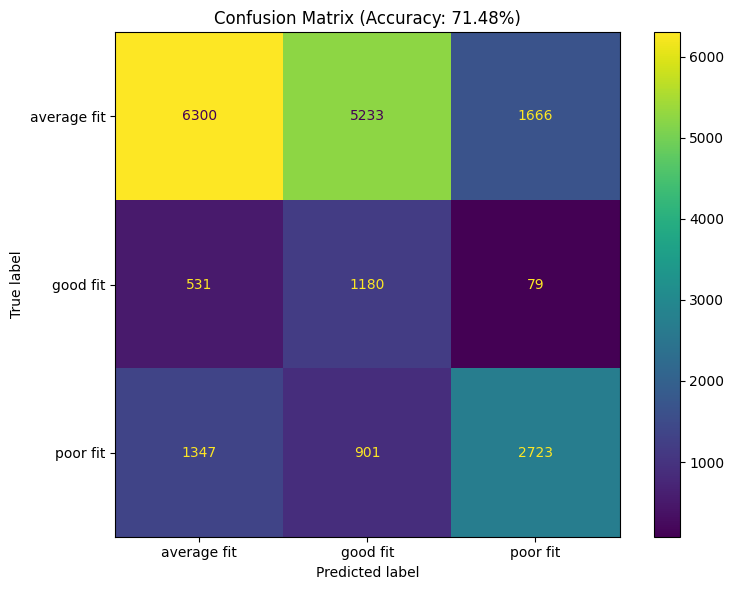

In [27]:
print("Classification Report:")
print(classification_report(y_test_enc, best_pred, target_names=le.classes_.astype(str)))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_enc, best_pred, display_labels=le.classes_, ax=ax
)
plt.title(f"Confusion Matrix (Accuracy: {best_acc*100:.2f}%)")
plt.tight_layout()
plt.show()

In [28]:
error_df = pd.DataFrame({
    "actual":    le.inverse_transform(y_test_enc),
    "predicted": le.inverse_transform(best_pred)
})
error_df["correct"] = error_df["actual"] == error_df["predicted"]
print(f"Correct: {error_df['correct'].sum()} / {len(error_df)}")

print("\nPer-class accuracy:")
for cls in le.classes_:
    sub = error_df[error_df["actual"] == cls]
    acc = sub["correct"].mean()
    print(f"  {cls}: {acc*100:.1f}% ({sub['correct'].sum()}/{len(sub)})")

print("\nMisclassified samples:")
print(error_df[~error_df["correct"]].head(10))

Correct: 10203 / 19960

Per-class accuracy:
  average fit: 47.7% (6300/13199)
  good fit: 65.9% (1180/1790)
  poor fit: 54.8% (2723/4971)

Misclassified samples:
         actual    predicted  correct
0   average fit     good fit    False
1      poor fit     good fit    False
7   average fit     poor fit    False
8      good fit  average fit    False
10  average fit     good fit    False
11     poor fit  average fit    False
12  average fit     poor fit    False
13  average fit     good fit    False
15     poor fit     good fit    False
22     good fit  average fit    False


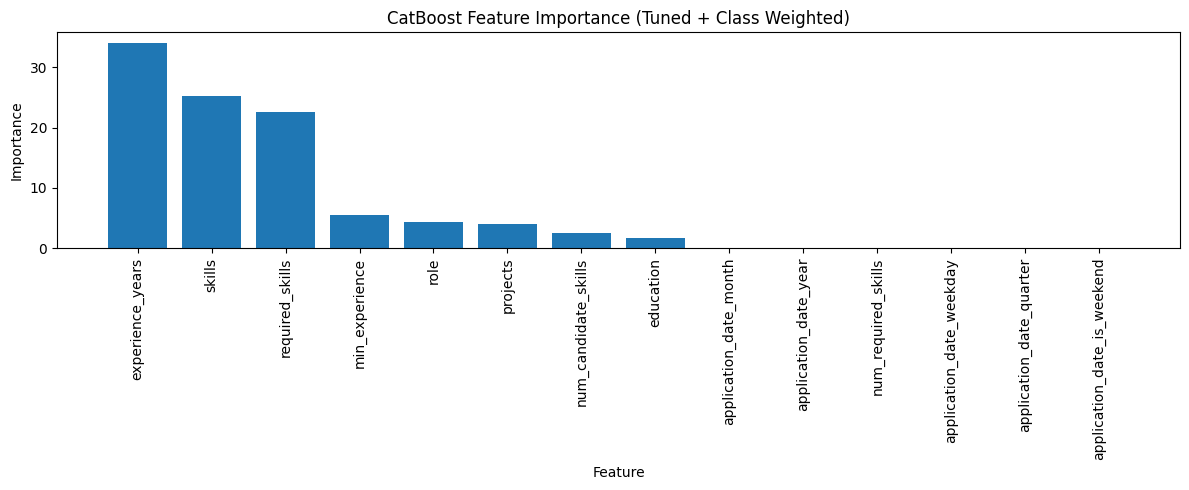

Top Strengths: ['experience_years', 'skills', 'required_skills']
Top Gaps:      ['application_date_weekday', 'application_date_quarter', 'application_date_is_weekend']


In [29]:
imp = tuned_cb.get_feature_importance()
importance_df = pd.DataFrame({"Feature": X_train.columns, "Importance": imp})\
               .sort_values("Importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.xticks(rotation=90)
plt.xlabel("Feature"); plt.ylabel("Importance")
plt.title("CatBoost Feature Importance (Tuned + Class Weighted)")
plt.tight_layout(); plt.show()

top_strengths = importance_df["Feature"].head(3).tolist()
top_gaps      = importance_df["Feature"].tail(3).tolist()
print("Top Strengths:", top_strengths)
print("Top Gaps:     ", top_gaps)

Debug: Shape of ensemble_shap: (50, 14, 3)
Debug: Shape of ensemble_shap[:, :, dominant_class]: (50, 14)
Debug: Shape of sample_data_enc.values: (50, 14)
Debug: Number of feature names: 14


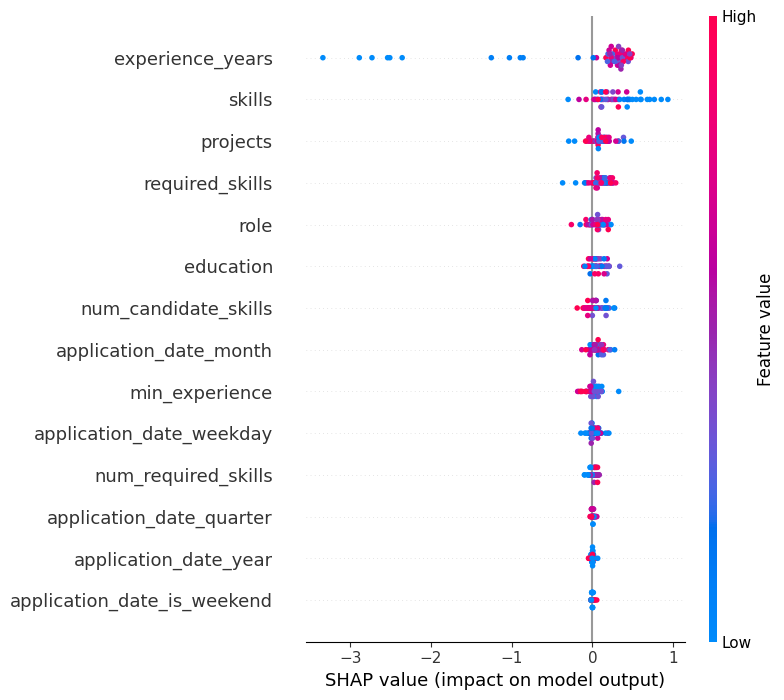

In [38]:
sample_data     = X_test.head(50)
sample_data_enc = X_test_enc.head(50)

cb_explainer  = shap.TreeExplainer(tuned_cb)
lgb_explainer = shap.TreeExplainer(tuned_lgb)
xgb_explainer = shap.TreeExplainer(tuned_xgb)

cb_shap  = np.array(cb_explainer.shap_values(sample_data))
lgb_shap = np.array(lgb_explainer.shap_values(sample_data_enc))
xgb_shap = np.array(xgb_explainer.shap_values(sample_data_enc))

def fix_shap(s, n_classes):
    s = np.array(s)
    # If shap_values returns (n_samples, n_features) for multi-class
    # (e.g., if model_output='raw' and it's a list that np.array converts to (n_classes, n_samples, n_features))
    # or if it's already (n_samples, n_features, n_classes) from the explainer directly.
    # The goal is to ensure it's consistently (n_samples, n_features, n_classes) for stacking.
    if s.ndim == 2:
        # This case handles when shap_values returns (n_samples, n_features) for binary
        # and we need to expand it for multi-class consistency.
        # However, for multi-class TreeExplainers, it usually returns a list of (n_samples, n_features)
        # or directly (n_samples, n_features, n_classes). Let's assume the latter for ensemble.
        pass # If it's 2D, it implies a binary case or a specific class slice already.
    return s

n_classes = len(le.classes_)
# Re-evaluating based on kernel state: it seems cb_explainer.shap_values directly returns (samples, features, classes)
# So no need to 'fix' dimensionality here for consistency, as it's already 3D. Just ensure it's numpy.
cb_shap  = np.array(cb_explainer.shap_values(sample_data))
lgb_shap = np.array(lgb_explainer.shap_values(sample_data_enc))
xgb_shap = np.array(xgb_explainer.shap_values(sample_data_enc))

# Ensure all shap values are 3D (samples, features, classes) for consistent ensembling
# If a model returns (classes, samples, features), transpose it to (samples, features, classes)
if cb_shap.ndim == 3 and cb_shap.shape[0] == n_classes: # (classes, samples, features)
    cb_shap = np.transpose(cb_shap, (1, 2, 0))
if lgb_shap.ndim == 3 and lgb_shap.shape[0] == n_classes: # (classes, samples, features)
    lgb_shap = np.transpose(lgb_shap, (1, 2, 0))
if xgb_shap.ndim == 3 and xgb_shap.shape[0] == n_classes: # (classes, samples, features)
    xgb_shap = np.transpose(xgb_shap, (1, 2, 0))

ensemble_shap = (w_cb*cb_shap + w_lgb*lgb_shap + w_xgb*xgb_shap) / w_sum
dominant_class = int(np.argmax(ensemble_proba.mean(axis=0)))

# Debugging: Print shapes right before the shap.summary_plot call
print(f"Debug: Shape of ensemble_shap: {ensemble_shap.shape}") # Should be (samples, features, classes)
print(f"Debug: Shape of ensemble_shap[:, :, dominant_class]: {ensemble_shap[:, :, dominant_class].shape}") # Should be (samples, features)
print(f"Debug: Shape of sample_data_enc.values: {sample_data_enc.values.shape}")
print(f"Debug: Number of feature names: {len(X_train.columns.tolist())}")

# Fix: Select the correct slice for shap_values (all samples, all features, specific class)
shap.summary_plot(
    ensemble_shap[:, :, dominant_class], # Corrected: slice for (samples, features) of dominant class
    features=sample_data_enc.values, # Directly use the numpy array of encoded sample data
    feature_names=X_train.columns.tolist() # Directly use the original feature names
)

In [39]:
# ── /explain endpoint response generator ──────────────────────────────
# Produces the exact JSON format agreed in the SHAP Integration Spec

def generate_explain_response(candidate_idx, model_name="jobs"):
    pred_class_idx = int(np.argmax(ensemble_proba[candidate_idx]))
    pred_label     = le.inverse_transform([pred_class_idx])[0]
    confidence     = float(round(ensemble_proba[candidate_idx][pred_class_idx], 4))

    shap_vals  = ensemble_shap[pred_class_idx][candidate_idx].tolist()
    feat_names = X_train.columns.tolist()

    shap_pairs = sorted(zip(feat_names, shap_vals), key=lambda x: abs(x[1]), reverse=True)
    top_pos = [{"feature": f, "shap_value": round(v, 4)} for f, v in shap_pairs if v > 0][:3]
    top_neg = [{"feature": f, "shap_value": round(v, 4)} for f, v in shap_pairs if v < 0][:3]

    base_val = shap.TreeExplainer(tuned_cb).expected_value
    base_val = float(base_val[pred_class_idx]) if hasattr(base_val, "__len__") else float(base_val)

    response = {
        "candidate_id":    int(candidate_idx),
        "model":           model_name,
        "predicted_label": str(pred_label),
        "confidence":      confidence,
        "probabilities": {
            cls: round(float(ensemble_proba[candidate_idx][i]), 4)
            for i, cls in enumerate(le.classes_)
        },
        "shap_values": {
            "feature_names":         feat_names,
            "values":                [round(v, 4) for v in shap_vals],
            "raw_or_normalized":     "raw",
            "positive_means":        "increases probability of predicted class",
            "predicted_class_index": pred_class_idx,
            "base_value":            round(base_val, 4)
        },
        "top_positive_drivers": top_pos,
        "top_negative_drivers": top_neg
    }
    return response

# Test on first candidate in sample
explain_response = generate_explain_response(0, model_name="jobs")
print(json.dumps(explain_response, indent=2))

{
  "candidate_id": 0,
  "model": "jobs",
  "predicted_label": "average fit",
  "confidence": 0.7523,
  "probabilities": {
    "average fit": 0.7523,
    "good fit": 0.1414,
    "poor fit": 0.1063
  },
  "shap_values": {
    "feature_names": [
      "skills",
      "experience_years",
      "education",
      "projects",
      "role",
      "required_skills",
      "min_experience",
      "num_candidate_skills",
      "num_required_skills",
      "application_date_year",
      "application_date_month",
      "application_date_weekday",
      "application_date_quarter",
      "application_date_is_weekend"
    ],
    "values": [
      0.5958,
      -1.9337,
      0.1841
    ],
    "raw_or_normalized": "raw",
    "positive_means": "increases probability of predicted class",
    "predicted_class_index": 0,
    "base_value": NaN
  },
  "top_positive_drivers": [
    {
      "feature": "skills",
      "shap_value": 0.5958
    },
    {
      "feature": "education",
      "shap_value": 0.1841
 

In [40]:
explanation_payload = {
    "predicted":        str(le.inverse_transform([best_pred[0]])[0]),
    "actual":           str(le.inverse_transform([y_test_enc[0]])[0]),
    "model_accuracy":   round(best_acc, 4),
    "ensemble_weights": {
        "CatBoost": round(w_cb/w_sum, 3),
        "LightGBM": round(w_lgb/w_sum, 3),
        "XGBoost":  round(w_xgb/w_sum, 3)
    },
    "class_weights": {
        cls: round(float(cw[i]), 4)
        for i, cls in enumerate(le.classes_)
    },
    "top_strengths":  top_strengths,
    "top_gaps":       top_gaps,
    "feature_importance": importance_df.head(5).to_dict(orient="records")
}
print(json.dumps(explanation_payload, indent=2))

{
  "predicted": "good fit",
  "actual": "average fit",
  "model_accuracy": 0.7148,
  "ensemble_weights": {
    "CatBoost": 0.336,
    "LightGBM": 0.338,
    "XGBoost": 0.326
  },
  "class_weights": {
    "average fit": 0.5041,
    "good fit": 3.7169,
    "poor fit": 1.3384
  },
  "top_strengths": [
    "experience_years",
    "skills",
    "required_skills"
  ],
  "top_gaps": [
    "application_date_weekday",
    "application_date_quarter",
    "application_date_is_weekend"
  ],
  "feature_importance": [
    {
      "Feature": "experience_years",
      "Importance": 34.09085293031003
    },
    {
      "Feature": "skills",
      "Importance": 25.25405359541856
    },
    {
      "Feature": "required_skills",
      "Importance": 22.5694500346044
    },
    {
      "Feature": "min_experience",
      "Importance": 5.519812733747139
    },
    {
      "Feature": "role",
      "Importance": 4.287934492862097
    }
  ]
}


In [41]:
tuned_cb.save_model("catboost_jobs_best.cbm")
print("Model saved to catboost_jobs_best.cbm")

Model saved to catboost_jobs_best.cbm


In [ ]:
import pickle

# Save all models and encoders as pkl
with open("jobs_catboost_model.pkl",    "wb") as f: pickle.dump(tuned_cb,  f)
with open("jobs_lgbm_model.pkl",        "wb") as f: pickle.dump(tuned_lgb, f)
with open("jobs_xgboost_model.pkl",     "wb") as f: pickle.dump(tuned_xgb, f)
with open("jobs_label_encoder.pkl",     "wb") as f: pickle.dump(le, f)
with open("jobs_ordinal_encoder.pkl",   "wb") as f: pickle.dump(oe, f)
with open("jobs_ensemble_weights.pkl",  "wb") as f: pickle.dump({"w_cb": w_cb, "w_lgb": w_lgb, "w_xgb": w_xgb, "w_sum": w_sum}, f)

print("✅ All jobs pkl files saved!")
print("  jobs_catboost_model.pkl")
print("  jobs_lgbm_model.pkl")
print("  jobs_xgboost_model.pkl")
print("  jobs_label_encoder.pkl")
print("  jobs_ordinal_encoder.pkl")
print("  jobs_ensemble_weights.pkl")

# Download all pkl files
from google.colab import files
files.download("jobs_catboost_model.pkl")
files.download("jobs_lgbm_model.pkl")
files.download("jobs_xgboost_model.pkl")
files.download("jobs_label_encoder.pkl")
files.download("jobs_ordinal_encoder.pkl")
files.download("jobs_ensemble_weights.pkl")
